In [1]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import torch

drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/cleaned_diabetes_dataset.csv"
df = pd.read_csv(file_path)

Mounted at /content/drive


In [2]:
# 2. Define Features (X) and Target (y)
# Assuming 'diabetes' is the target column
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include='object').columns

# Apply one-hot encoding to the entire feature set before splitting
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [3]:
# 3. Split into Train and Temp (30% for Val+Test)
# Using stratify=y to ensure class proportions are maintained
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

In [4]:
# 4. Split Temp into Validation and Test (50/50 of the 30% -> 15% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [5]:
# 5. Handle Imbalance using SMOTE (Only on Training Data!)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

/tmp/ipykernel_1039/522204703.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=ax1, palette='viridis')
/tmp/ipykernel_1039/522204703.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_balanced, ax=ax2, palette='viridis')


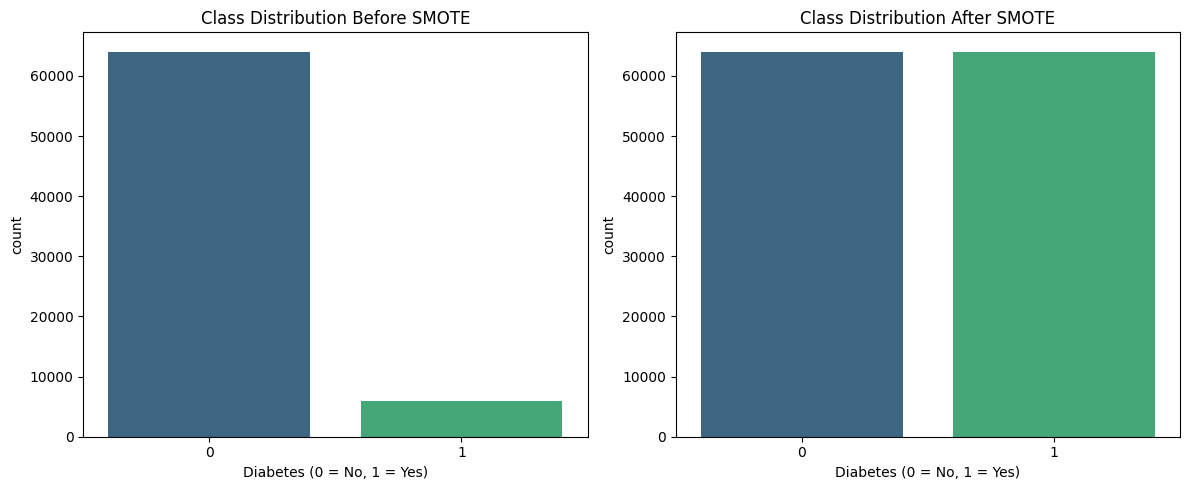

In [6]:
# 6. Visualize the Class Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot before SMOTE
sns.countplot(x=y_train, ax=ax1, palette='viridis')
ax1.set_title('Class Distribution Before SMOTE')
ax1.set_xlabel('Diabetes (0 = No, 1 = Yes)')

# Plot after SMOTE
sns.countplot(x=y_train_balanced, ax=ax2, palette='viridis')
ax2.set_title('Class Distribution After SMOTE')
ax2.set_xlabel('Diabetes (0 = No, 1 = Yes)')

plt.tight_layout()
plt.show()

In [7]:
# 7. Convert DataFrames/Series to PyTorch Tensors
# Ensure data is cast to float32 for neural network compatibility
X_train_final = torch.tensor(X_train_balanced.astype(float).values, dtype=torch.float32)
y_train_final = torch.tensor(y_train_balanced.astype(float).values, dtype=torch.float32)

X_val_final = torch.tensor(X_val.astype(float).values, dtype=torch.float32)
y_val_final = torch.tensor(y_val.astype(float).values, dtype=torch.float32)

X_test_final = torch.tensor(X_test.astype(float).values, dtype=torch.float32)
y_test_final = torch.tensor(y_test.astype(float).values, dtype=torch.float32)

# Summary Report
print("-" * 30)
print("DATASET SUMMARY")
print("-" * 30)
print(f"Original training shape:   {X_train.shape}")
print(f"Balanced training shape:   {X_train_balanced.shape}")
print(f"Training Tensor:           {X_train_final.shape}")
print(f"Validation Tensor:         {X_val_final.shape}")
print(f"Testing Tensor:            {X_test_final.shape}")
print("-" * 30)

------------------------------
DATASET SUMMARY
------------------------------
Original training shape:   (69987, 12)
Balanced training shape:   (128074, 12)
Training Tensor:           torch.Size([128074, 12])
Validation Tensor:         torch.Size([14997, 12])
Testing Tensor:            torch.Size([14998, 12])
------------------------------


In [8]:
# 8. Save Tensors to Google Drive for the Modelling Stage
processed_data_path = "/content/drive/MyDrive/diabetes_processed_tensors.pt"

# Pack all tensors into a single dictionary file
torch.save({
    'X_train': X_train_final,
    'y_train': y_train_final,
    'X_val': X_val_final,
    'y_val': y_val_final,
    'X_test': X_test_final,
    'y_test': y_test_final
}, processed_data_path)

print(f"Success! All 6 tensors successfully saved to: {processed_data_path}")

Success! All 6 tensors successfully saved to: /content/drive/MyDrive/diabetes_processed_tensors.pt
